<a href="https://colab.research.google.com/github/Brunoxue/hsi_examples/blob/main/ATGP_LS_tite.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Get dataset from Github repo
!git clone https://github.com/Brunoxue/tite.git

Cloning into 'tite'...
remote: Enumerating objects: 8, done.
remote: Counting objects: 100% (8/8), done.
remote: Compressing objects: 100% (7/7), done.
remote: Total 8 (delta 0), reused 8 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (8/8), 40.42 MiB | 17.04 MiB/s, done.


In [ ]:
import numpy as np
from scipy.io import loadmat
import matplotlib.pyplot as plt

# Load the hyperspectral data
data = loadmat('tite/tite_reflectance.mat')
hsi = data['TI3'].astype(float)
minerals = data['minerals'].astype(float)

minerals_label = [index_label[i][0][0] for i in range(5)]

In [ ]:
from scipy.linalg import sqrtm, inv
from scipy.special import erfinv
from sklearn.decomposition import NMF

# Automatic Target Generation Process (ATGP)
def ATGP(HSI,p):
  '''
  HSI: Hyperspectral Image
  p: Number of targets
  '''
  (x,y,L)=HSI.shape
  N=x*y
  r=np.reshape(HSI,(N,L))

  idxTgt = [np.argmax(np.sum(r*r,axis=1))]
  spTgt = r[idxTgt,:].squeeze()

  for idx in range(1,6):
    U = spTgt.T

    if U.ndim == 1:
      P_U_per = np.eye(L)-U@U.T/(U.T@U)
    else:
      P_U_per = np.eye(L)-U@np.linalg.pinv(U.T@U)@U.T

    scoreATGP = r@P_U_per*r
    idxNewTgt = np.argmax(np.sum(scoreATGP,axis=1))

    spTgt=np.vstack((spTgt,r[idxNewTgt,:].squeeze()))
    idxTgt.append(idxNewTgt)

  posTgt = np.unravel_index(idxTgt, (x,y), order='C')

  return posTgt, spTgt.T

# Non-negative Constrained Least Squares (NCLS)
def NCLS(HSI, M):
    x, y, L = HSI.shape
    p = M.shape[1]

    N = x * y
    r = HSI.reshape(N, L).T

    from scipy.optimize import lsq_linear

    abundanceNCLS = np.zeros((N, p))
    for idx in range(N):
        result = lsq_linear(M, r[:, idx], bounds=(0, np.inf), method='bvls')
        abundanceNCLS[idx, :] = result.x

    abundanceNCLS = abundanceNCLS.reshape(x, y, p)

    return abundanceNCLS

# Fully Constrained Least Squares (FCLS)
def FCLS(HSI, M):
    x, y, L = HSI.shape
    p = M.shape[1]
    N = x * y
    r = HSI.reshape(N, L).T

    M = np.vstack([M, np.ones((1, p))])
    r = np.vstack([r, np.ones((1, N))])

    from scipy.optimize import lsq_linear

    abundanceFCLS = np.zeros((N, p))
    for idx in range(N):
        result = lsq_linear(M, r[:, idx], bounds=(0, np.inf), method='bvls')
        abundanceFCLS[idx, :] = result.x

    abundanceFCLS = abundanceFCLS.reshape(x, y, p)

    return abundanceFCLS

# Nonnegative Matrix Factorization
def NMF_Unmixing(HSI, M, abd_init = None):
    x, y, L = HSI.shape
    p = M.shape[1]
    N = x * y
    r = HSI.reshape(N, L).T

    M = np.vstack([M, 6000 * np.ones((1, p))])
    r = np.vstack([r, 6000 * np.ones((1, N))])

    if abd_init is None:
      abd_init = np.random.rand(N, p)
    else:
      abd_init = abd_init.reshape(N, p)

    # Apply NMF
    nmf = NMF(n_components=p, init='custom', max_iter = 1000)
    abundanceNMF = nmf.fit_transform(r.T, W=abd_init, H=M.T)
    spTgtNMF = nmf.components_.T

    abundanceNMF = np.reshape(abundanceNMF, (x, y, p))

    return abundanceNMF, spTgtNMF[0:L,:]

In [ ]:
# Functions for Benchmark Criteria
from sklearn.preprocessing import normalize
import pandas as pd

def NMSE(HSI, abundanceMap, spTgt):
  L = HSI.shape[2]
  (x,y,p)=abundanceMap.shape
  N=x*y
  hsi_reconstructed = abundanceNCLS.reshape(N,p) @ spTgt.T

  NMSE=np.linalg.norm(hsi.reshape(N,L)-hsi_reconstructed, 'fro')/np.linalg.norm(hsi.reshape(N,L), 'fro')
  # print(NMSE)
  return NMSE

def SAM_Emb(minerals, spTgt):
  M = normalize(minerals, axis=0, copy=True)
  M_ATGP = normalize(spTgt, axis=0, copy=True)
  results_sam = np.arccos(np.sqrt(M.T@M_ATGP))

  return np.min(results_sam,axis=1)

def RMSE_Emb(emb_predict, emb_gt):
  # return np.sqrt(np.mean((emb_predict - emb_gt) ** 2))
  p = emb_gt.shape[1]
  n = emb_predict.shape[1]
  rmse = np.zeros((p,n))
  for idx_p in range(p):
    d = emb_gt[:, idx_p]
    for idx_n in range(n):
      r = emb_predict[:, idx_n]
      rmse[idx_p, idx_n] = np.sqrt(np.mean((d - r) ** 2))

  return np.min(rmse, axis=0)


# Endmember Extraction with ATGP

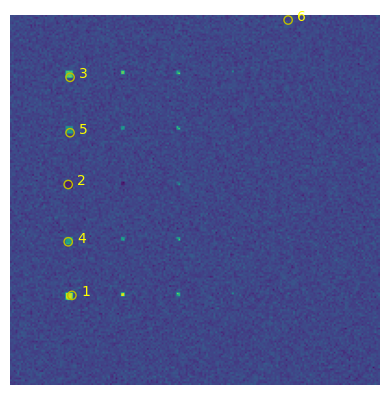

   SA (Endmember)  RMSE (Endmember)
A        0.013449         83.532080
B        0.014526         78.859228
C        0.019137         81.325787
K        0.015194         88.100412
M        0.013459         89.449344


In [ ]:
# ATGP
# Define the number of endmembers (estimated by NWHFC)
posTgt, spTgt = ATGP(hsi,6)

# Display found endmember location
plt.figure()
plt.imshow(hsi[:, :, 100])
plt.axis('off')
for idx in range(6):
    plt.scatter(posTgt[1][idx], posTgt[0][idx], facecolors='none', edgecolors='y')  # Plot target points
    plt.text(posTgt[1][idx] + 5, posTgt[0][idx], str(idx + 1), color='yellow')  # Label target points
plt.show()

# Display endmember extraction performance
sams = SAM_Emb(minerals, spTgt)
rmses = RMSE_Emb(minerals, spTgt)

metrics_emb = {
    'SA (Endmember)': sams,
    'RMSE (Endmember)': rmses,
}
metrics_df = pd.DataFrame(metrics_emb, index=minerals_label)
print(metrics_df)

# Unmixing with NCLS

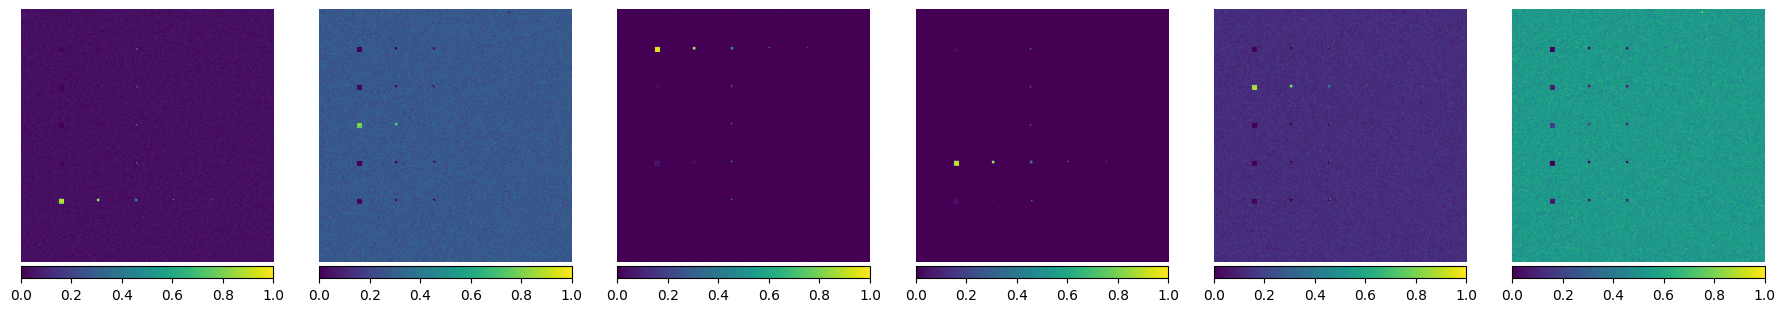

NMSE (Reconstruction):  0.031209598020558324


In [ ]:
# NCLS
# Compute the NCLS abundance maps
abundanceNCLS = NCLS(hsi, spTgt)
# Plot the abundance maps for NCLS
fig, axs = plt.subplots(nrows=1, ncols=6, figsize=(18, 4), subplot_kw={'xticks': [], 'yticks': []})
for idx in range(6):
    im = axs[idx].imshow(abundanceNCLS[:, :, idx], cmap='viridis')
    axs[idx].axis('off')
    fig.colorbar(im, ax=axs[idx], orientation='horizontal', pad=0.01)
plt.tight_layout()
plt.show()

# Benchmark Criterias
print("NMSE (Reconstruction): ",NMSE(hsi, abundanceNCLS, spTgt))

# Unmixing with FCLS

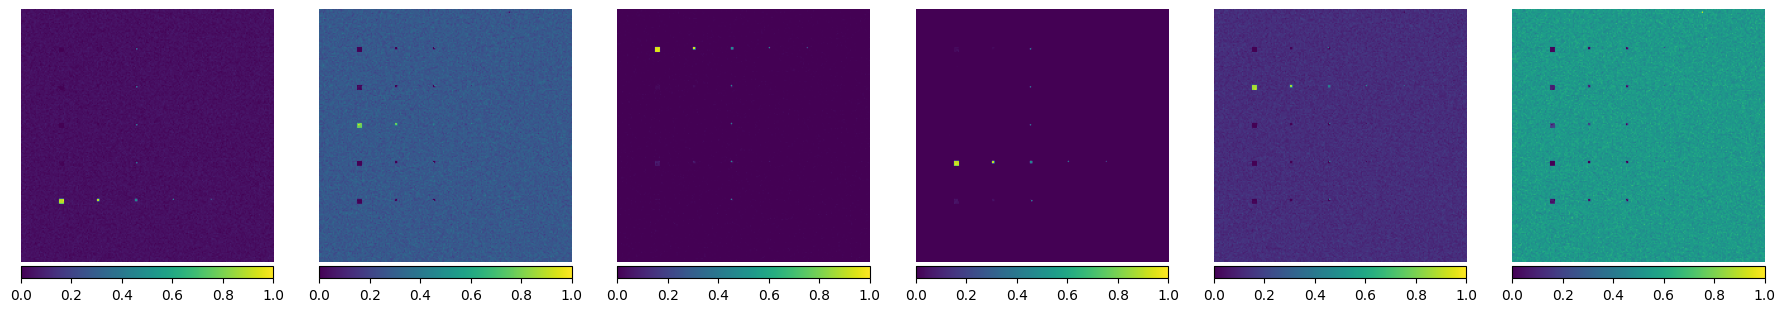

NMSE (Reconstruction):  0.031209598020558324


In [ ]:
# FCLS
# Compute the FCLS abundance maps
abundanceFCLS = FCLS(hsi, spTgt)
# Plot the abundance maps for FCLS
fig, axs = plt.subplots(nrows=1, ncols=6, figsize=(18, 4), subplot_kw={'xticks': [], 'yticks': []})
for idx in range(6):
    im = axs[idx].imshow(abundanceFCLS[:, :, idx], cmap='viridis')
    axs[idx].axis('off')
    fig.colorbar(im, ax=axs[idx], orientation='horizontal', pad=0.01)
plt.tight_layout()
plt.show()

# Benchmark Criterias
print("NMSE (Reconstruction): ",NMSE(hsi, abundanceFCLS, spTgt))

# Unmixing with NMF

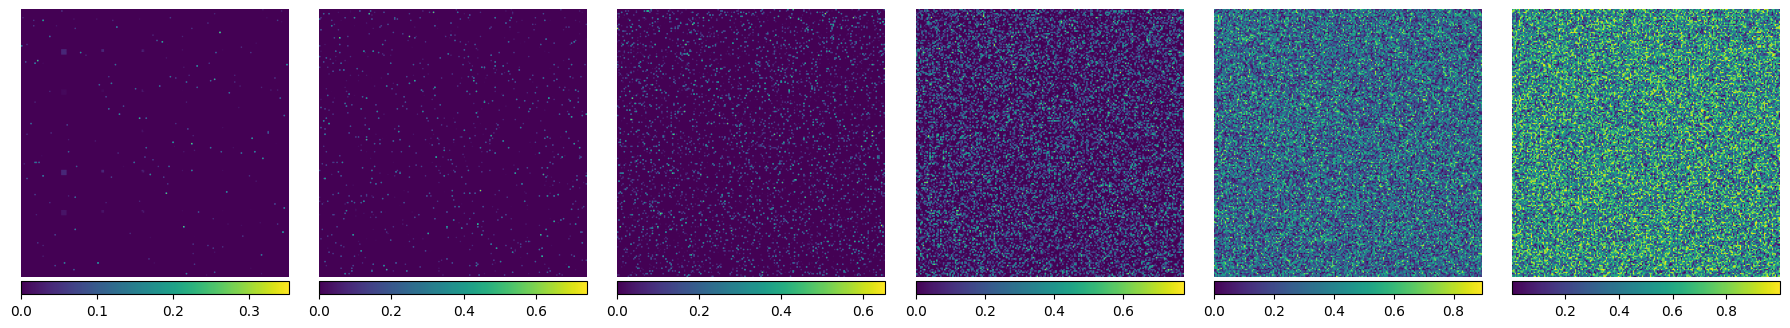

   SA (Endmember)  RMSE (Endmember)
A        0.058812        471.952529
B        0.045898        251.108526
C        0.028696        121.136029
K        0.062532        666.621794
M        0.047341        310.564204
NMSE (Reconstruction):  0.026656640382120827


In [ ]:
# NMF
abundanceNMF, spTgtNMF = NMF_Unmixing(hsi, spTgt)

# Plot the abundance maps for NMF
fig, axs = plt.subplots(nrows=1, ncols=6, figsize=(18, 4), subplot_kw={'xticks': [], 'yticks': []})
for idx in range(6):
    im = axs[idx].imshow(abundanceNMF[:, :, idx], cmap='viridis')
    axs[idx].axis('off')
    fig.colorbar(im, ax=axs[idx], orientation='horizontal', pad=0.01)
plt.tight_layout()
plt.show()

# Display endmember extraction performance
sams = SAM_Emb(minerals, spTgtNMF)
rmses = RMSE_Emb(minerals, spTgtNMF)

metrics_emb = {
    'SA (Endmember)': sams,
    'RMSE (Endmember)': rmses,
}
metrics_df = pd.DataFrame(metrics_emb, index=minerals_label)
print(metrics_df)
print("NMSE (Reconstruction): ", NMSE(hsi, abundanceNMF, spTgtNMF))